In [1]:
from option import Option, OptionParams
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from scipy.integrate import cumulative_trapezoid

def make_plot(data, xlab = '', ylab = '', zlab = ''):
    
    X, Y, z = data
    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(projection="3d")
    ax.view_init(elev=25)

    surf = ax.plot_surface(
        X, Y, z,
        cmap="plasma",
        antialiased=True
    )
    ax.plot_wireframe(
        X, Y, z,
        rstride=10,
        cstride=10,
        color="black",
        alpha=0.35
    )
    ax.set_box_aspect((2.5, 2.5, 1))
    
    ax.set_xlabel(xlab, labelpad=10)
    ax.set_ylabel(ylab, labelpad=10)
    ax.set_zlabel(zlab, labelpad=10)
    plt.title(f'{zlab} depending on ' + xlab + ' and ' + ylab)

    fig.colorbar(surf, shrink=0.6, aspect=15, pad = 0.12)
    plt.tight_layout()

    plt.show()

## Option class requires a parameters dataclass 

In [2]:
parameters = OptionParams(
    under = 690.62,
    strike = 691,
    dividend = 0.0105,
    maturity = 1,
    rate  = 0.0345,
    volatility = 0.1462,
    call = True,
    name = "SP500"
)
option1 = Option(parameters)

In [3]:
option1.get_info()


                                 SP500                          
        | Metric                    |                     Value |
        ---------------------------------------------------------
        | Price                     |                    €47.79 |
        | Strike                    |                   €691.00 |
        | Time to maturity          |                      1.00 |
        | Delta                     |                  0.586125 |
        | Gamma                     |                  0.003805 |
        | Vega                      |                265.307884 |
        | Theta                     |                -27.460310 |
        | Rho                       |                357.002807 |
        | Call or put               |                      Call |
        


## brown_simul() simulates the underlying price of the option

57


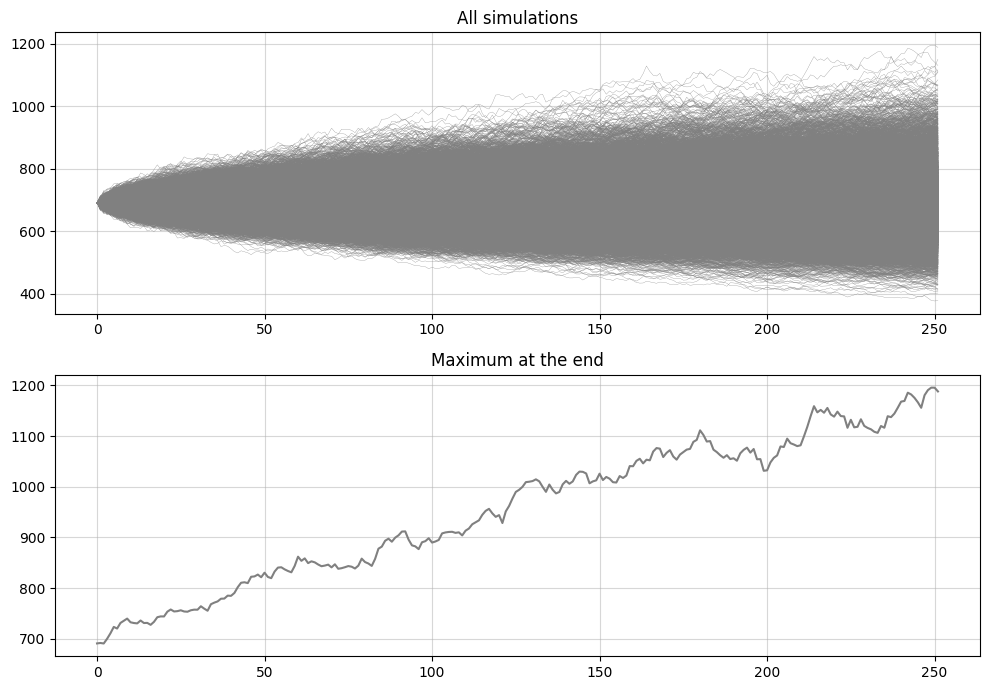

In [4]:
#   brown_simul(n_simuls=250, n_steps = 252 * time to maturity, drift = risk free rate - divident yield, sigma = volatility )

paths = option1.brown_simul(n_simuls=10000, drift=0)
maximum = max(paths[-1, :])
for i in range(10000):
    if paths[-1, i] == maximum:
        print(i)
        idx = i
plt.figure(figsize=(10, 7))
plt.subplot(2, 1, 1)
plt.plot(paths, linewidth = 0.2, c = 'grey')
plt.title("All simulations")
plt.grid(alpha = 0.5)
plt.subplot(2, 1, 2)
plt.plot(paths[:, idx], c = 'grey')
plt.title("Maximum at the end")
plt.grid(alpha = 0.5)
plt.tight_layout()
plt.show()

## The final values of the simulations can be investigated further

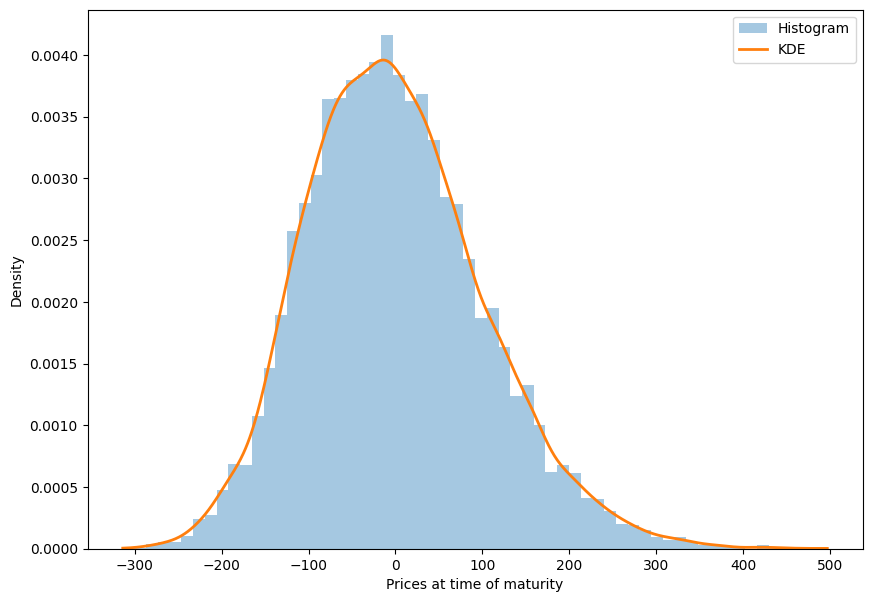

In [5]:

last = paths[-1, :] # final values are the prices of the underlying at the time of maturity
x = np.asarray(last) - parameters.strike # price of the underlying at the time of maturity minus the strike price gives the earnings if the option is exercised.
kde = gaussian_kde(x)

x_grid = np.linspace(x.min(), x.max(), 1000)
pdf = kde(x_grid)

plt.figure(figsize=(10, 7))
plt.hist(x, bins=60, density=True, alpha=0.4, label="Histogram")
plt.plot(x_grid, pdf, lw=2, label="KDE")
plt.legend()
plt.xlabel("Prices at time of maturity")
plt.ylabel("Density")
plt.show()

## The kernal density function can be used to obtain a cumulative trapeziod to compute cut offs at certain percentiles at will

In [6]:

cdf = cumulative_trapezoid(pdf, x_grid, initial=0)

def kde_quantile(q, x_grid, cdf):
    return np.interp(q, cdf, x_grid)
q10 = kde_quantile(0.10, x_grid, cdf)
q50 = kde_quantile(0.50, x_grid, cdf)
q90 = kde_quantile(0.90, x_grid, cdf)

print(q10, q50, q90)


-124.78454979550504 -7.619171524131569 136.1527462929781


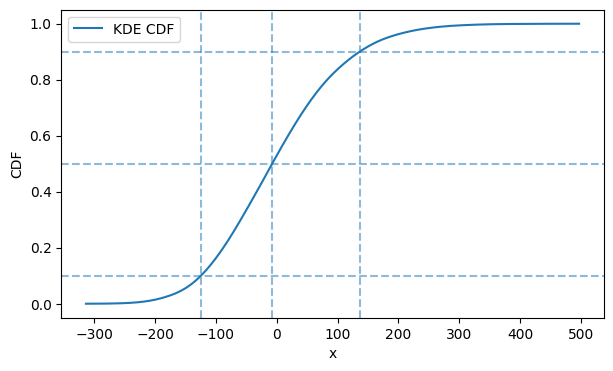

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(x_grid, cdf, label="KDE CDF")

for q in [0.1, 0.5, 0.9]:
    plt.axhline(q, ls="--", alpha=0.5)
    plt.axvline(kde_quantile(q, x_grid, cdf), ls="--", alpha=0.5)

plt.xlabel("x")
plt.ylabel("CDF")
plt.legend()
plt.show()


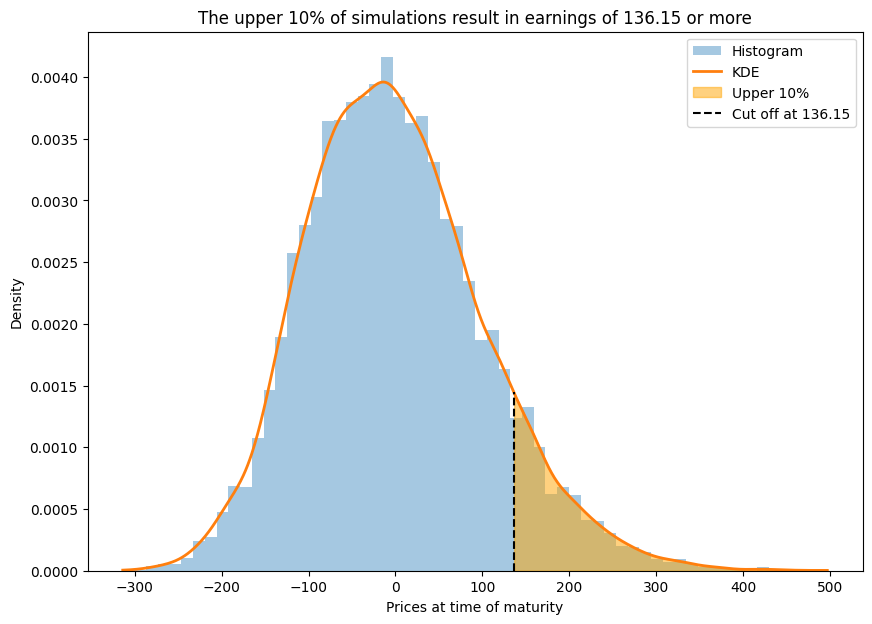

In [8]:
x_grid = np.linspace(x.min(), x.max(), 1000)
pdf = kde(x_grid)

plt.figure(figsize=(10, 7))
plt.hist(x, bins=60, density=True, alpha=0.4, label="Histogram")
plt.plot(x_grid, pdf, lw=2, label="KDE")
plt.fill_between(x_grid[x_grid > q90], pdf[x_grid >q90], color='orange', alpha=0.5, label="Upper 10%")
ymin, ymax = plt.ylim()
plt.axvline(x = q90, ymin = ymin, ymax = kde(q90)[0]/ ymax, c = 'black', linestyle = '--', label = f'Cut off at {q90:.2f}')
plt.legend()
plt.xlabel("Prices at time of maturity")
plt.ylabel("Density")
plt.title(f"The upper 10% of simulations result in earnings of {q90:.2f} or more")
plt.show()

## price_simul() calls the brown_simul() function and translates it to prices of the option

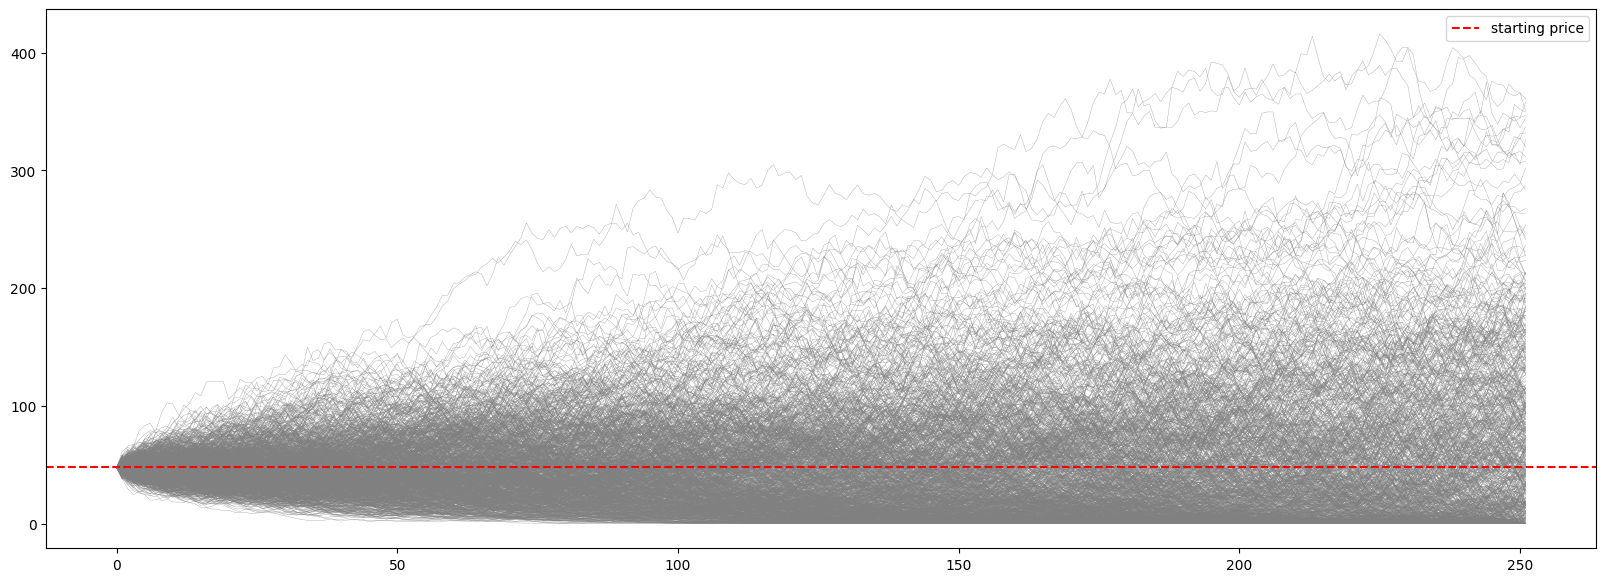

In [9]:
_, prices = option1.price_simul(n_simuls=1000)
plt.figure(figsize=(20, 7))
plt.plot(prices, linewidth = 0.2, c = 'grey')
plt.axhline(option1.price(), linestyle = "--", c = 'red', label = "starting price")
plt.legend()
plt.show()

## Final values represent the payoffs which can be used to compute the profits of the theoretical simulations

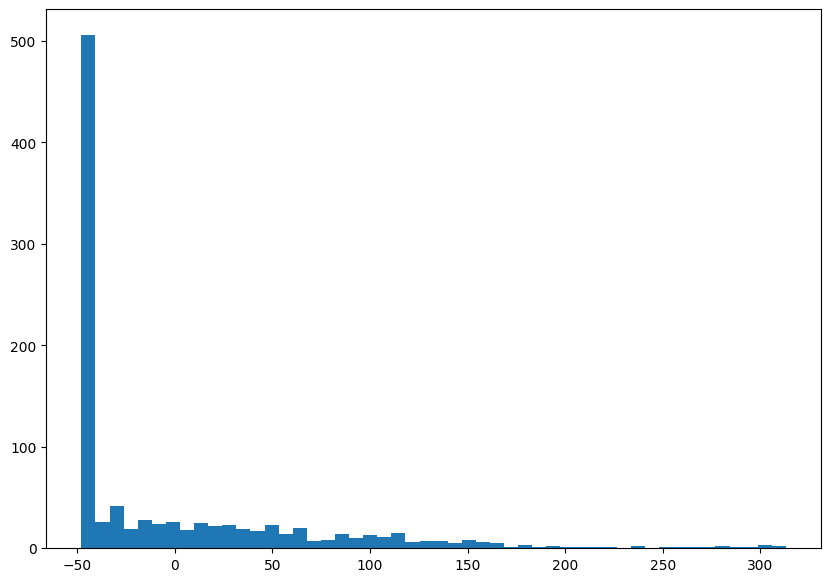

In [10]:
payoff = prices[-1, :]

profit = payoff - option1.price()
plt.figure(figsize=(10, 7))
plt.hist(profit, bins = 50)
plt.show()

## The custom make_plot() function can be used to plot the option price based on two independent variables: Strike, time to maturity, underlying price and volatility

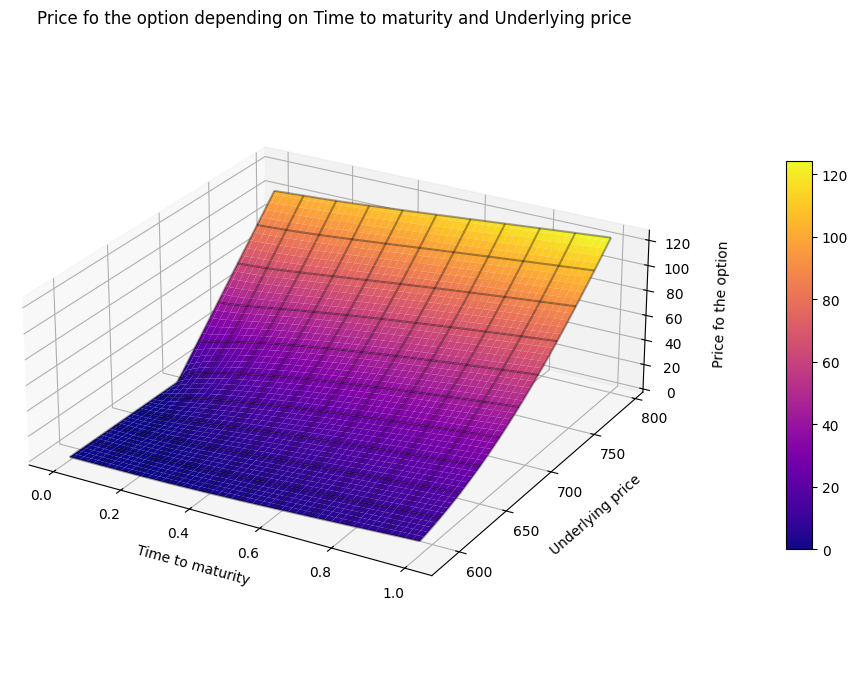

In [11]:
plot_data = option1.plot_3d(xax = "M", yax = "U") 

make_plot(data = plot_data, xlab = "Time to maturity", ylab = "Underlying price", zlab = "Price fo the option")

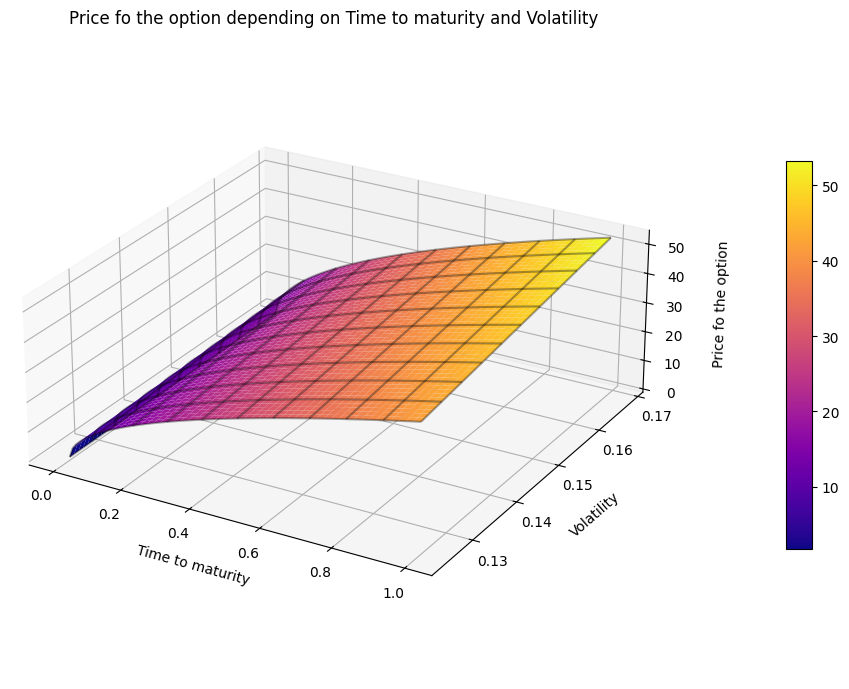

In [12]:
plot_data = option1.plot_3d(xax = "M", yax = "V")

make_plot(data = plot_data, xlab = "Time to maturity", ylab = "Volatility", zlab = "Price fo the option")

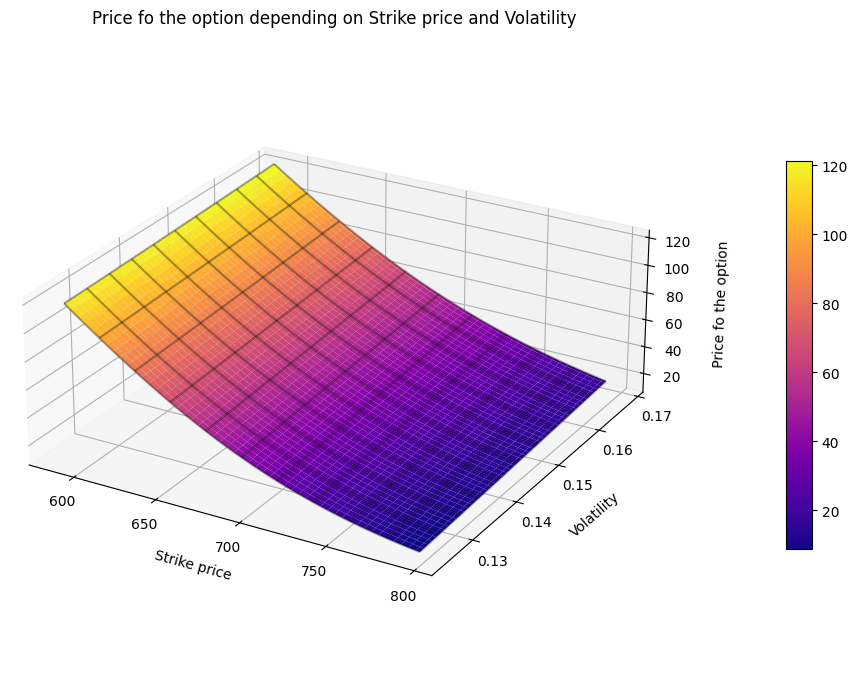

In [13]:
plot_data = option1.plot_3d(xax = "S", yax = "V") 

make_plot(data = plot_data, xlab = "Strike price", ylab = "Volatility", zlab = "Price fo the option")

## The z-axis can display the option price, delta, gamma, vega, theta or rho for any of the combinations of the variables specified in the x-axis and the y-axis

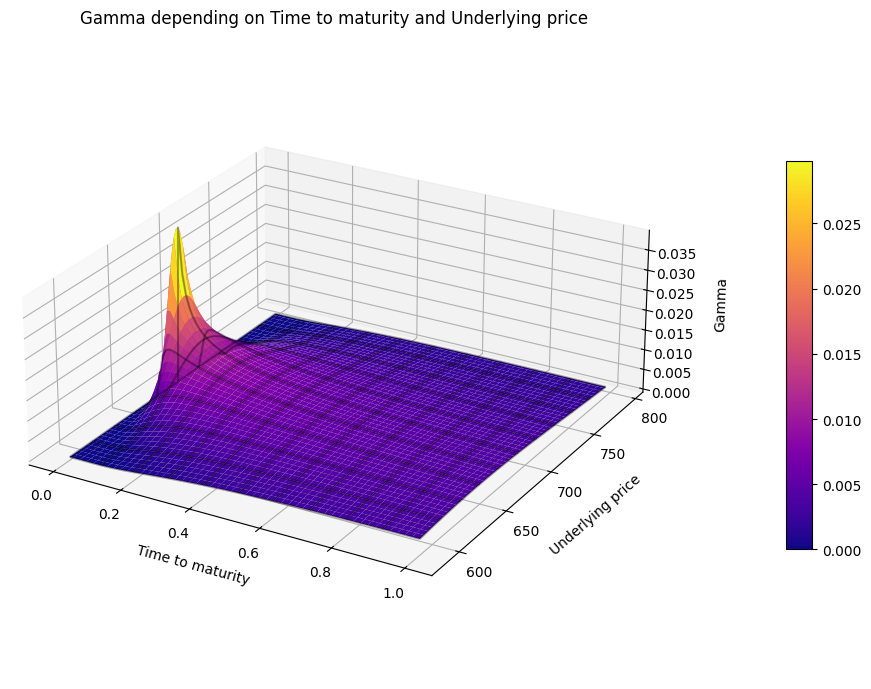

In [14]:
plot_data = option1.plot_3d(xax = "M", yax = "U", zax="gamma")

make_plot(data = plot_data, xlab = "Time to maturity", ylab = "Underlying price", zlab = "Gamma")

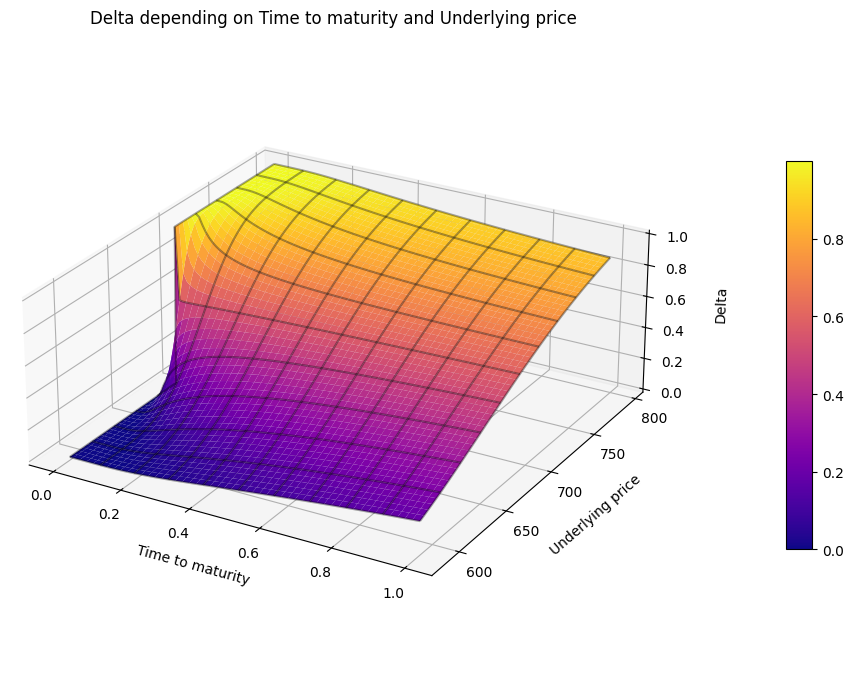

In [15]:
plot_data = option1.plot_3d(xax = "M", yax = "U", zax="delta")

make_plot(data = plot_data, xlab = "Time to maturity", ylab = "Underlying price", zlab = "Delta")

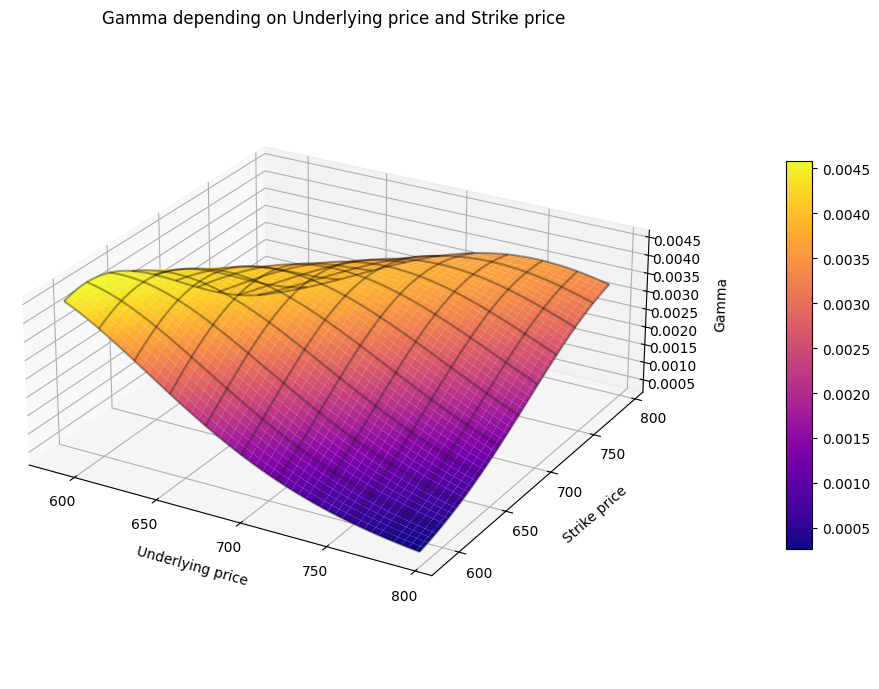

In [16]:
plot_data = option1.plot_3d(xax = "U", yax = "S", zax="gamma")

make_plot(data = plot_data, xlab = "Underlying price", ylab = "Strike price", zlab = "Gamma")